# Tema 7: Redes en Biología y Ecología

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from scipy import linalg

# Configuración de gráficos
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## Ejercicio 1: Modelo de depredación preferente

### Descripción del modelo físico

Las redes tróficas describen las relaciones de depredación en un ecosistema: quién come a quién. Una propiedad fundamental de estas redes es su **coherencia trófica**, que mide qué tan bien definida está la estructura en niveles (productores primarios → herbívoros → carnívoros → superdepredadores).

**Nivel trófico** de cada especie:
$$s_i = \frac{1}{k_i^{in}}\sum_j a_{ij} s_j + 1$$

donde $a_{ij} = 1$ si la especie $i$ se come a la especie $j$, y $k_i^{in}$ es el número de presas de $i$. Las especies basales (sin presas) tienen $s = 1$.

**Distancia trófica** de un enlace:
$$x = s_{depredador} - s_{presa}$$

**Parámetro de incoherencia trófica**:
$$q = \sqrt{\langle x^2 \rangle - 1}$$

- $q = 0$: red perfectamente coherente (todos los enlaces conectan niveles adyacentes)
- $q > 0$: red incoherente (hay enlaces que saltan varios niveles o van "hacia atrás")

### Modelo de depredación preferente

Este modelo genera redes tróficas con coherencia controlable mediante el parámetro de **tolerancia trófica** $T$.

**Parámetros:**
- $N$: número total de especies
- $B$: número de especies basales
- $L$: número total de enlaces
- $T$: tolerancia trófica (parámetro de control)

**Algoritmo:**
1. Crear $B$ especies basales con nivel trófico $s = 1$
2. Para cada nueva especie $i$:
   - Elegir una primera presa $j$ al azar entre las especies basales
   - Elegir presas adicionales $l$ con probabilidad $p_{il} = \exp(-|s_j - s_l|/T)$
   - Calcular el nivel trófico de $i$: $s_i = \langle s_{presas} \rangle + 1$
3. Continuar hasta tener $L$ enlaces

**Efecto de T:**
- $T \to 0$: alta coherencia (depredadores solo comen presas del mismo nivel)
- $T \to \infty$: baja coherencia (depredadores comen presas de cualquier nivel)

### Estabilidad

La estabilidad de un ecosistema se analiza mediante la **matriz de interacción**:
$$W_{ij} = \eta a_{ij} - a_{ji}$$

donde $\eta$ es la eficiencia de depredación (fracción de biomasa que gana el depredador).

El sistema es estable si $R = \text{Re}(\lambda_{max}(W)) < 0$.

### Objetivo

1. Implementar el modelo de depredación preferente
2. Estudiar cómo $T$ controla la coherencia $q$
3. Analizar la relación entre coherencia y estabilidad

In [13]:
# ============================================
# Funciones para calcular propiedades tróficas
# ============================================

@njit
def compute_trophic_levels(adj_matrix, basal_species):
    """
    Calcula los niveles tróficos de todas las especies.
    
    adj_matrix[i,j] = 1 si i come a j (i es depredador, j es presa)
    
    Nivel trófico: s_i = (1/k_in) * sum_j(a_ij * s_j) + 1
    Para especies basales: s = 1
    """
    N = adj_matrix.shape[0]
    levels = np.ones(N)  # Inicializar todos a 1
    
    # Iterar hasta convergencia
    for iteration in range(100):
        new_levels = np.ones(N)
        
        for i in range(N):
            if basal_species[i]:
                new_levels[i] = 1.0
            else:
                # Calcular número de presas (in-degree)
                k_in = 0
                sum_levels = 0.0
                for j in range(N):
                    if adj_matrix[i, j] == 1:
                        k_in += 1
                        sum_levels += levels[j]
                
                if k_in > 0:
                    new_levels[i] = sum_levels / k_in + 1.0
                else:
                    new_levels[i] = 1.0
        
        # Verificar convergencia
        max_diff = 0.0
        for i in range(N):
            diff = abs(new_levels[i] - levels[i])
            if diff > max_diff:
                max_diff = diff
        
        levels = new_levels.copy()
        
        if max_diff < 1e-10:
            break
    
    return levels


@njit
def compute_trophic_coherence(adj_matrix, levels):
    """
    Calcula el parámetro de incoherencia trófica q.
    
    q = sqrt(<x^2> - 1)
    
    donde x = s_depredador - s_presa para cada enlace.
    """
    N = adj_matrix.shape[0]
    
    sum_x2 = 0.0
    n_links = 0
    
    for i in range(N):
        for j in range(N):
            if adj_matrix[i, j] == 1:
                x = levels[i] - levels[j]  # depredador - presa
                sum_x2 += x * x
                n_links += 1
    
    if n_links == 0:
        return 0.0
    
    mean_x2 = sum_x2 / n_links
    
    # q = sqrt(<x^2> - 1)
    if mean_x2 < 1.0:
        return 0.0
    
    return np.sqrt(mean_x2 - 1.0)


def compute_stability(adj_matrix, eta=0.1):
    """
    Calcula la estabilidad del ecosistema.
    
    Matriz de interacción: W_ij = eta * a_ij - a_ji
    
    Retorna R = Re(lambda_max(W))
    Sistema estable si R < 0
    """
    W = eta * adj_matrix - adj_matrix.T
    
    # Calcular autovalores
    eigenvalues = linalg.eigvals(W)
    
    # Parte real máxima
    R = np.max(np.real(eigenvalues))
    
    return R

print("Funciones de análisis trófico definidas.")

Funciones de análisis trófico definidas.


In [14]:
# ============================================
# Modelo de depredación preferente
# ============================================

def preferential_predation_model(N, B, L, T, seed=None):
    """
    Genera una red trófica usando el modelo de depredación preferente.
    
    Parámetros:
    -----------
    N : int
        Número total de especies
    B : int
        Número de especies basales
    L : int
        Número de enlaces objetivo
    T : float
        Tolerancia trófica (T → 0: coherente, T → ∞: incoherente)
    
    Retorna:
    --------
    adj_matrix : array (N, N)
        Matriz de adyacencia (adj[i,j] = 1 si i come a j)
    levels : array (N,)
        Niveles tróficos
    basal : array (N,)
        Máscara de especies basales
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Inicializar
    adj_matrix = np.zeros((N, N), dtype=np.float64)
    levels = np.ones(N)
    basal = np.zeros(N, dtype=np.bool_)
    basal[:B] = True
    
    # Lista de especies existentes (empezamos con las basales)
    species_added = list(range(B))
    current_links = 0
    
    # Añadir especies consumidoras
    for i in range(B, N):
        if current_links >= L:
            break
        
        # Primera presa: elegir al azar entre las basales
        first_prey = np.random.randint(0, B)
        adj_matrix[i, first_prey] = 1
        current_links += 1
        
        # Nivel de referencia
        ref_level = levels[first_prey]
        
        # Presas adicionales con probabilidad proporcional a exp(-|s_ref - s_l|/T)
        for j in species_added:
            if j == first_prey:
                continue
            if current_links >= L:
                break
            
            # Probabilidad de depredar j
            if T > 1e-10:
                prob = np.exp(-abs(ref_level - levels[j]) / T)
            else:
                # T = 0: solo presas del mismo nivel
                prob = 1.0 if abs(ref_level - levels[j]) < 0.01 else 0.0
            
            # Escalar probabilidad para controlar número de enlaces
            prob *= min(1.0, (L - current_links) / (N - i) / 2)
            
            if np.random.random() < prob:
                adj_matrix[i, j] = 1
                current_links += 1
        
        # Calcular nivel trófico de la nueva especie
        prey_indices = np.where(adj_matrix[i, :] == 1)[0]
        if len(prey_indices) > 0:
            levels[i] = np.mean(levels[prey_indices]) + 1
        else:
            levels[i] = 1
            basal[i] = True
        
        species_added.append(i)
    
    # Añadir enlaces adicionales si faltan
    attempts = 0
    while current_links < L and attempts < L * 10:
        attempts += 1
        
        # Elegir depredador (no basal)
        predator = np.random.randint(B, N)
        
        # Elegir presa potencial
        prey = np.random.randint(0, N)
        
        # No auto-loops, no duplicados, el depredador debe tener nivel mayor
        if prey != predator and adj_matrix[predator, prey] == 0:
            # Probabilidad basada en diferencia de niveles
            if T > 1e-10:
                # Preferir presas de nivel menor
                if levels[predator] > levels[prey]:
                    diff = abs(1.0 - (levels[predator] - levels[prey]))
                    prob = np.exp(-diff / T)
                    if np.random.random() < prob:
                        adj_matrix[predator, prey] = 1
                        current_links += 1
                        # Recalcular nivel del depredador
                        prey_indices = np.where(adj_matrix[predator, :] == 1)[0]
                        if len(prey_indices) > 0:
                            levels[predator] = np.mean(levels[prey_indices]) + 1
            else:
                # T = 0: solo enlaces que mantienen coherencia
                if abs(levels[predator] - levels[prey] - 1.0) < 0.01:
                    adj_matrix[predator, prey] = 1
                    current_links += 1
    
    # Recalcular niveles finales
    levels = compute_trophic_levels(adj_matrix, basal)
    
    return adj_matrix, levels, basal

print("Modelo de depredación preferente definido.")

Modelo de depredación preferente definido.


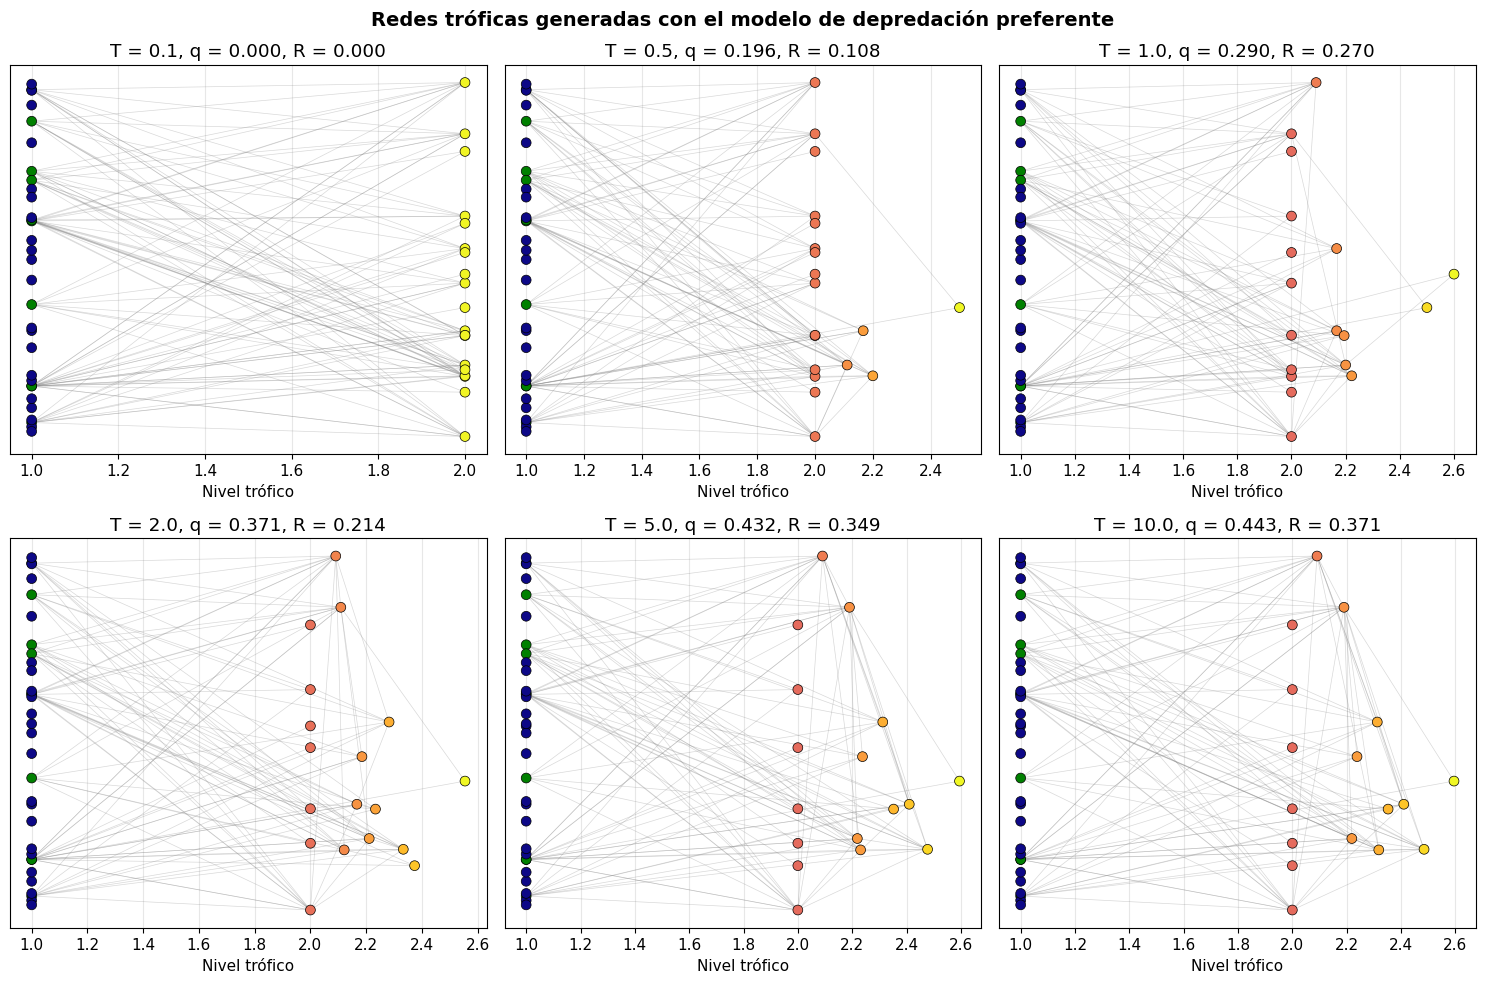


Figura 1: Redes tróficas para diferentes valores de tolerancia T.
Modelo: N = 50 especies, B = 10 basales, L = 100 enlaces objetivo.
T pequeño: alta coherencia (q ≈ 0), estructura en niveles clara.
T grande: baja coherencia (q > 0), enlaces cruzan múltiples niveles.


In [15]:
# ============================================
# Ejemplo: generar y visualizar una red trófica
# ============================================

N = 50   # Especies
B = 10   # Basales
L = 100  # Enlaces

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

T_values = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

for idx, T in enumerate(T_values):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Generar red
    adj, levels, basal = preferential_predation_model(N, B, L, T, seed=42)
    
    # Calcular coherencia
    q = compute_trophic_coherence(adj, levels)
    
    # Calcular estabilidad
    R = compute_stability(adj, eta=0.1)
    
    # Número real de enlaces
    n_links = int(np.sum(adj))
    
    # Visualizar: posición x = nivel trófico, y = aleatorio
    np.random.seed(42)
    y_pos = np.random.uniform(0, 1, N)
    x_pos = levels
    
    # Dibujar enlaces
    for i in range(N):
        for j in range(N):
            if adj[i, j] == 1:
                ax.plot([x_pos[j], x_pos[i]], [y_pos[j], y_pos[i]], 
                        'gray', alpha=0.3, lw=0.5)
    
    # Dibujar nodos
    colors = ['green' if basal[i] else plt.cm.plasma((levels[i]-1)/(np.max(levels)-1+0.01)) 
              for i in range(N)]
    ax.scatter(x_pos, y_pos, c=colors, s=50, zorder=5, edgecolors='black', linewidths=0.5)
    
    ax.set_xlabel('Nivel trófico')
    ax.set_ylabel('')
    ax.set_title(f'T = {T}, q = {q:.3f}, R = {R:.3f}')
    ax.set_yticks([])

plt.suptitle('Redes tróficas generadas con el modelo de depredación preferente', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nFigura 1: Redes tróficas para diferentes valores de tolerancia T.")
print(f"Modelo: N = {N} especies, B = {B} basales, L = {L} enlaces objetivo.")
print(f"T pequeño: alta coherencia (q ≈ 0), estructura en niveles clara.")
print(f"T grande: baja coherencia (q > 0), enlaces cruzan múltiples niveles.")

Calculando coherencia vs tolerancia...


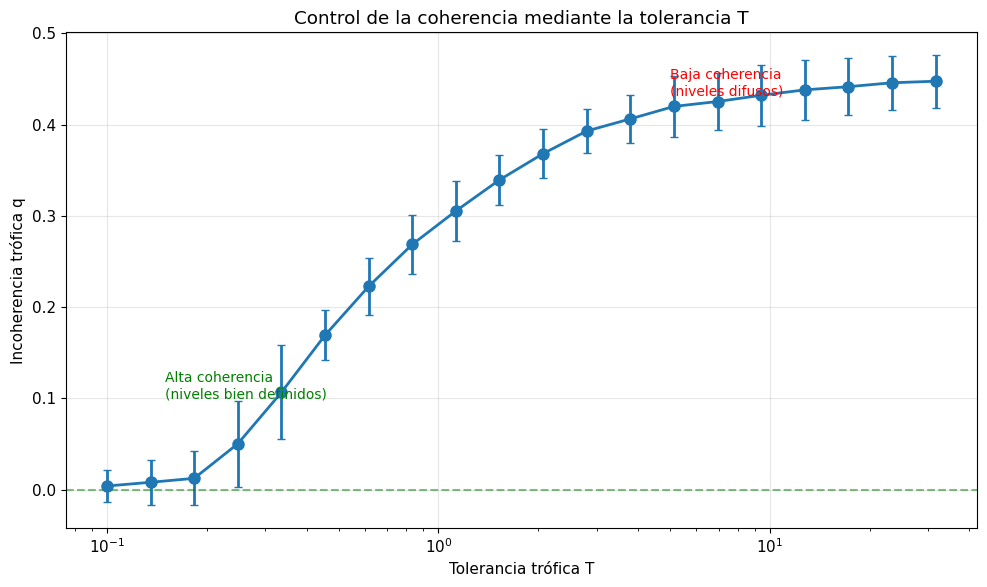


Figura 2: Incoherencia trófica q en función de la tolerancia T.
Modelo: N = 50, B = 10, L = 100, 20 realizaciones por punto.
La coherencia disminuye (q aumenta) al aumentar la tolerancia T.


In [16]:
# ============================================
# Relación T → q (coherencia)
# ============================================

N = 50
B = 10
L = 100
n_trials = 20

T_range = np.logspace(-1, 1.5, 20)  # De 0.1 a ~30

q_mean = []
q_std = []

print("Calculando coherencia vs tolerancia...")

for T in T_range:
    q_trials = []
    for trial in range(n_trials):
        adj, levels, basal = preferential_predation_model(N, B, L, T, seed=trial)
        q = compute_trophic_coherence(adj, levels)
        q_trials.append(q)
    
    q_mean.append(np.mean(q_trials))
    q_std.append(np.std(q_trials))

q_mean = np.array(q_mean)
q_std = np.array(q_std)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(T_range, q_mean, yerr=q_std, fmt='o-', capsize=3, markersize=8, lw=2)
ax.set_xscale('log')
ax.set_xlabel('Tolerancia trófica T')
ax.set_ylabel('Incoherencia trófica q')
ax.set_title('Control de la coherencia mediante la tolerancia T')

# Anotaciones
ax.axhline(0, color='green', linestyle='--', alpha=0.5, label='Coherencia perfecta (q=0)')
ax.annotate('Alta coherencia\n(niveles bien definidos)', 
            xy=(0.15, 0.1), fontsize=10, color='green')
ax.annotate('Baja coherencia\n(niveles difusos)', 
            xy=(5, q_mean[-5]), fontsize=10, color='red')

plt.tight_layout()
plt.show()

print(f"\nFigura 2: Incoherencia trófica q en función de la tolerancia T.")
print(f"Modelo: N = {N}, B = {B}, L = {L}, {n_trials} realizaciones por punto.")
print(f"La coherencia disminuye (q aumenta) al aumentar la tolerancia T.")

Calculando coherencia y estabilidad...


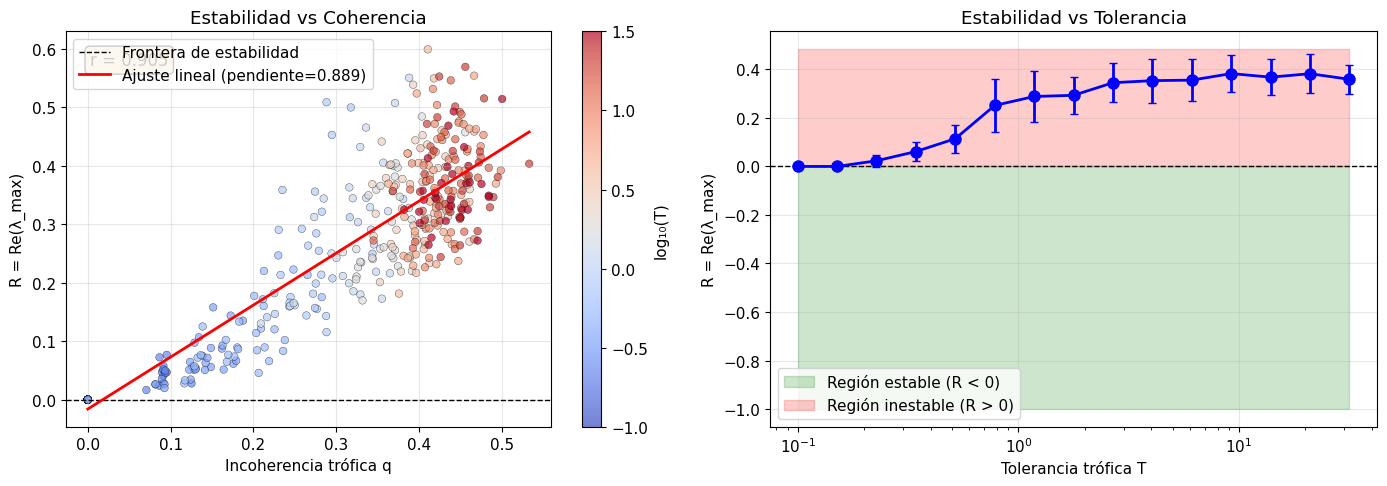


Figura 3: Relación entre coherencia trófica y estabilidad.
Modelo: N = 50, B = 10, L = 100, η = 0.1.
Correlación q-R: r = 0.905
Mayor coherencia (menor q) → Mayor estabilidad (menor R).


In [17]:
# ============================================
# Relación coherencia ↔ estabilidad
# ============================================

N = 50
B = 10
L = 100
n_trials = 30
eta = 0.1  # Eficiencia de depredación

T_range = np.logspace(-1, 1.5, 15)

all_q = []
all_R = []
all_T = []

print("Calculando coherencia y estabilidad...")

for T in T_range:
    for trial in range(n_trials):
        adj, levels, basal = preferential_predation_model(N, B, L, T, seed=trial*100 + int(T*10))
        
        q = compute_trophic_coherence(adj, levels)
        R = compute_stability(adj, eta=eta)
        
        all_q.append(q)
        all_R.append(R)
        all_T.append(T)

all_q = np.array(all_q)
all_R = np.array(all_R)
all_T = np.array(all_T)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: R vs q (scatter)
sc = axes[0].scatter(all_q, all_R, c=np.log10(all_T), cmap='coolwarm', 
                     alpha=0.7, s=30, edgecolors='black', linewidths=0.3)
axes[0].axhline(0, color='black', linestyle='--', lw=1, label='Frontera de estabilidad')
axes[0].set_xlabel('Incoherencia trófica q')
axes[0].set_ylabel('R = Re(λ_max)')
axes[0].set_title('Estabilidad vs Coherencia')
cbar = plt.colorbar(sc, ax=axes[0])
cbar.set_label('log₁₀(T)')

# Ajuste lineal
from numpy.polynomial import polynomial as P
coeffs = np.polyfit(all_q, all_R, 1)
q_fit = np.linspace(0, np.max(all_q), 100)
R_fit = coeffs[0] * q_fit + coeffs[1]
axes[0].plot(q_fit, R_fit, 'r-', lw=2, label=f'Ajuste lineal (pendiente={coeffs[0]:.3f})')
axes[0].legend()

# Calcular correlación
corr = np.corrcoef(all_q, all_R)[0, 1]
axes[0].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[0].transAxes, 
             fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat'))

# Panel 2: R promedio vs T
R_mean_per_T = []
R_std_per_T = []
for T in T_range:
    mask = all_T == T
    R_mean_per_T.append(np.mean(all_R[mask]))
    R_std_per_T.append(np.std(all_R[mask]))

axes[1].errorbar(T_range, R_mean_per_T, yerr=R_std_per_T, fmt='o-', 
                 capsize=3, markersize=8, lw=2, color='blue')
axes[1].axhline(0, color='black', linestyle='--', lw=1)
axes[1].set_xscale('log')
axes[1].set_xlabel('Tolerancia trófica T')
axes[1].set_ylabel('R = Re(λ_max)')
axes[1].set_title('Estabilidad vs Tolerancia')
axes[1].fill_between(T_range, -1, 0, alpha=0.2, color='green', label='Región estable (R < 0)')
axes[1].fill_between(T_range, 0, max(R_mean_per_T)+0.1, alpha=0.2, color='red', label='Región inestable (R > 0)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nFigura 3: Relación entre coherencia trófica y estabilidad.")
print(f"Modelo: N = {N}, B = {B}, L = {L}, η = {eta}.")
print(f"Correlación q-R: r = {corr:.3f}")
print(f"Mayor coherencia (menor q) → Mayor estabilidad (menor R).")

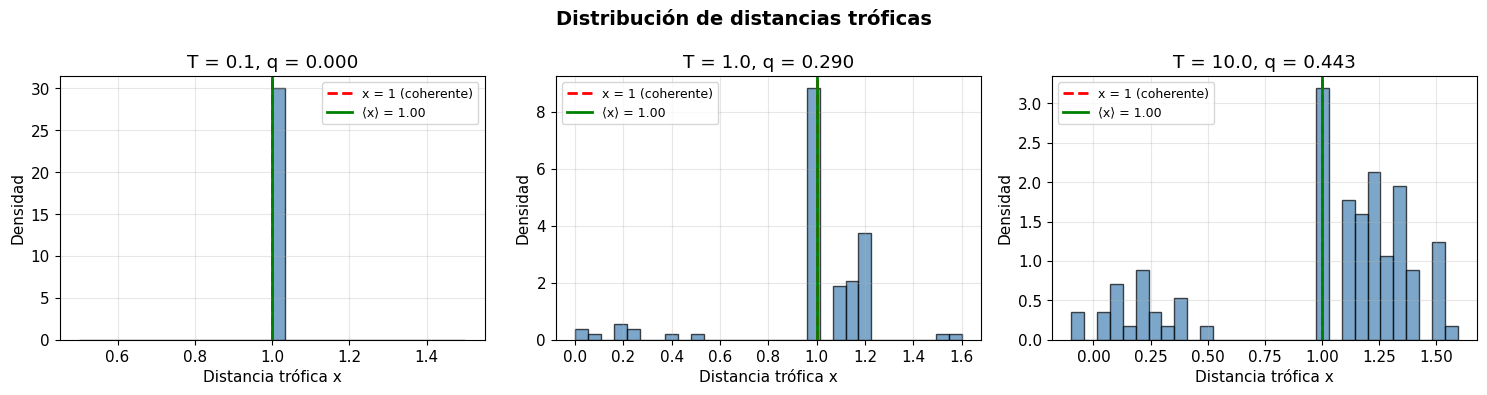


Figura 4: Distribución de distancias tróficas x = s_depredador - s_presa.
Red coherente (T pequeño): distribución centrada en x = 1.
Red incoherente (T grande): distribución amplia con x ≠ 1.


In [18]:
# ============================================
# Distribución de distancias tróficas
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

T_examples = [0.1, 1.0, 10.0]

for idx, T in enumerate(T_examples):
    ax = axes[idx]
    
    # Generar red
    adj, levels, basal = preferential_predation_model(N, B, L, T, seed=42)
    
    # Calcular distancias tróficas
    trophic_distances = []
    for i in range(N):
        for j in range(N):
            if adj[i, j] == 1:
                x = levels[i] - levels[j]
                trophic_distances.append(x)
    
    trophic_distances = np.array(trophic_distances)
    
    # Histograma
    ax.hist(trophic_distances, bins=30, density=True, alpha=0.7, 
            color='steelblue', edgecolor='black')
    ax.axvline(1, color='red', linestyle='--', lw=2, label='x = 1 (coherente)')
    ax.axvline(np.mean(trophic_distances), color='green', linestyle='-', lw=2, 
               label=f'⟨x⟩ = {np.mean(trophic_distances):.2f}')
    
    q = compute_trophic_coherence(adj, levels)
    ax.set_xlabel('Distancia trófica x')
    ax.set_ylabel('Densidad')
    ax.set_title(f'T = {T}, q = {q:.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de distancias tróficas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nFigura 4: Distribución de distancias tróficas x = s_depredador - s_presa.")
print(f"Red coherente (T pequeño): distribución centrada en x = 1.")
print(f"Red incoherente (T grande): distribución amplia con x ≠ 1.")

Estudiando efecto del tamaño...


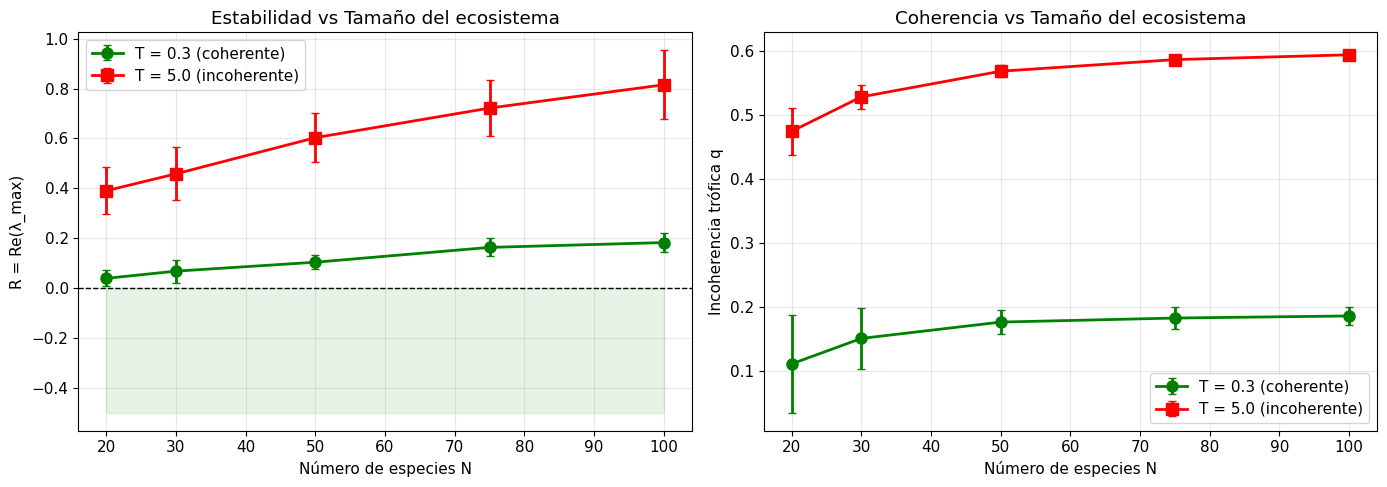


Figura 5: Efecto del tamaño del ecosistema en estabilidad y coherencia.
Densidad de enlaces constante = 0.1.
Redes coherentes mantienen estabilidad al crecer.
Redes incoherentes se vuelven más inestables al crecer (criterio de May).


In [19]:
# ============================================
# Efecto del tamaño en la estabilidad
# (Verificar si se cumple el criterio de May)
# ============================================

N_values = [20, 30, 50, 75, 100]
n_trials = 20

# Mantener densidad de enlaces constante
link_density = 0.1  # L / (N * (N-1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Para T bajo (coherente) y T alto (incoherente)
T_low = 0.3
T_high = 5.0

R_low = {N: [] for N in N_values}
R_high = {N: [] for N in N_values}
q_low = {N: [] for N in N_values}
q_high = {N: [] for N in N_values}

print("Estudiando efecto del tamaño...")

for N in N_values:
    B = max(3, N // 5)
    L = int(link_density * N * (N - 1))
    
    for trial in range(n_trials):
        # Red coherente
        adj, levels, basal = preferential_predation_model(N, B, L, T_low, seed=trial)
        R_low[N].append(compute_stability(adj, eta=0.1))
        q_low[N].append(compute_trophic_coherence(adj, levels))
        
        # Red incoherente
        adj, levels, basal = preferential_predation_model(N, B, L, T_high, seed=trial + 1000)
        R_high[N].append(compute_stability(adj, eta=0.1))
        q_high[N].append(compute_trophic_coherence(adj, levels))

# Panel 1: R vs N
R_low_mean = [np.mean(R_low[N]) for N in N_values]
R_low_std = [np.std(R_low[N]) for N in N_values]
R_high_mean = [np.mean(R_high[N]) for N in N_values]
R_high_std = [np.std(R_high[N]) for N in N_values]

axes[0].errorbar(N_values, R_low_mean, yerr=R_low_std, fmt='o-', capsize=3, 
                 markersize=8, lw=2, label=f'T = {T_low} (coherente)', color='green')
axes[0].errorbar(N_values, R_high_mean, yerr=R_high_std, fmt='s-', capsize=3, 
                 markersize=8, lw=2, label=f'T = {T_high} (incoherente)', color='red')
axes[0].axhline(0, color='black', linestyle='--', lw=1)
axes[0].set_xlabel('Número de especies N')
axes[0].set_ylabel('R = Re(λ_max)')
axes[0].set_title('Estabilidad vs Tamaño del ecosistema')
axes[0].legend()
axes[0].fill_between(N_values, -0.5, 0, alpha=0.1, color='green')

# Panel 2: q vs N
q_low_mean = [np.mean(q_low[N]) for N in N_values]
q_low_std = [np.std(q_low[N]) for N in N_values]
q_high_mean = [np.mean(q_high[N]) for N in N_values]
q_high_std = [np.std(q_high[N]) for N in N_values]

axes[1].errorbar(N_values, q_low_mean, yerr=q_low_std, fmt='o-', capsize=3, 
                 markersize=8, lw=2, label=f'T = {T_low} (coherente)', color='green')
axes[1].errorbar(N_values, q_high_mean, yerr=q_high_std, fmt='s-', capsize=3, 
                 markersize=8, lw=2, label=f'T = {T_high} (incoherente)', color='red')
axes[1].set_xlabel('Número de especies N')
axes[1].set_ylabel('Incoherencia trófica q')
axes[1].set_title('Coherencia vs Tamaño del ecosistema')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nFigura 5: Efecto del tamaño del ecosistema en estabilidad y coherencia.")
print(f"Densidad de enlaces constante = {link_density}.")
print(f"Redes coherentes mantienen estabilidad al crecer.")
print(f"Redes incoherentes se vuelven más inestables al crecer (criterio de May).")

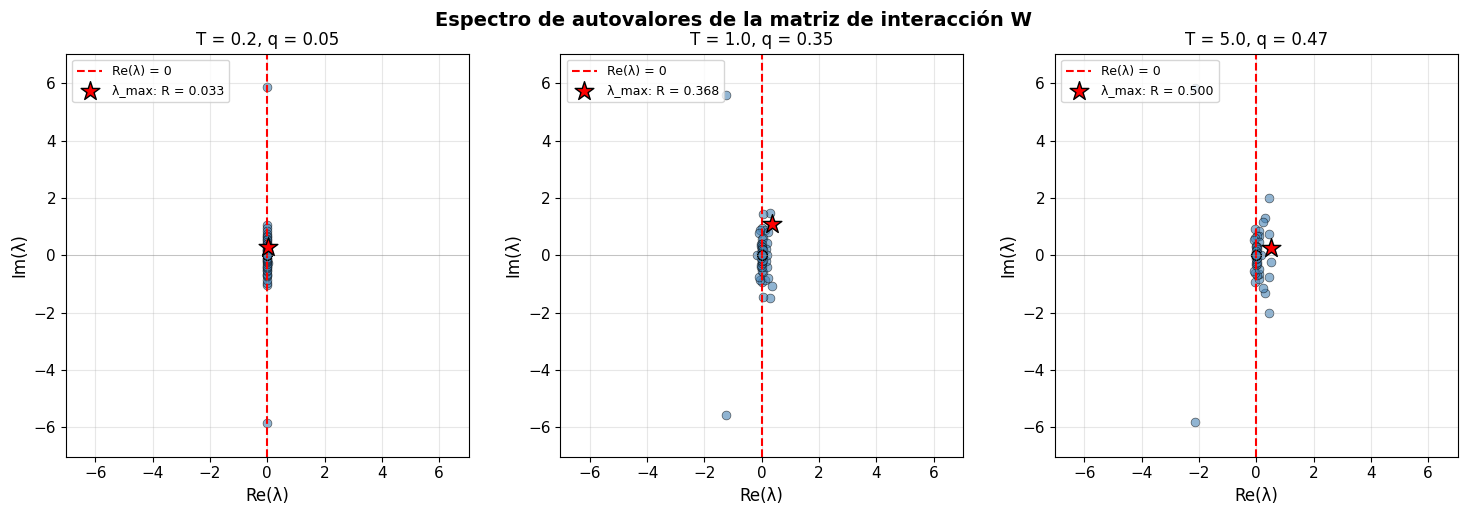


Figura 6: Espectro de autovalores en el plano complejo.
Modelo: N = 100, B = 20, L = 400, η = 0.1.
Red estable si todos los autovalores tienen Re(λ) < 0.
Mayor coherencia → autovalores más cerca del eje imaginario → más estable.


In [20]:
# ============================================
# Espectro de autovalores de la matriz de interacción
# ============================================

N = 100
B = 20
L = 400
eta = 0.1

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

T_examples = [0.2, 1.0, 5.0]

# Primero generar todas las redes para encontrar límites comunes
all_eigenvalues = []
for T in T_examples:
    adj, levels, basal = preferential_predation_model(N, B, L, T, seed=42)
    W = eta * adj - adj.T
    eigenvalues = linalg.eigvals(W)
    all_eigenvalues.append(eigenvalues)

# Encontrar límites comunes
all_real = np.concatenate([np.real(ev) for ev in all_eigenvalues])
all_imag = np.concatenate([np.imag(ev) for ev in all_eigenvalues])
max_abs = max(np.max(np.abs(all_real)), np.max(np.abs(all_imag))) * 1.2

for idx, T in enumerate(T_examples):
    ax = axes[idx]
    
    eigenvalues = all_eigenvalues[idx]
    
    # Generar red de nuevo para calcular q
    adj, levels, basal = preferential_predation_model(N, B, L, T, seed=42)
    q = compute_trophic_coherence(adj, levels)
    
    # Plot en plano complejo
    ax.scatter(np.real(eigenvalues), np.imag(eigenvalues), 
               alpha=0.6, s=40, c='steelblue', edgecolors='black', linewidths=0.5)
    ax.axvline(0, color='red', linestyle='--', lw=1.5, label='Re(λ) = 0')
    ax.axhline(0, color='gray', linestyle='-', lw=0.5, alpha=0.5)
    
    # Marcar λ_max
    R = np.max(np.real(eigenvalues))
    idx_max = np.argmax(np.real(eigenvalues))
    ax.scatter(np.real(eigenvalues[idx_max]), np.imag(eigenvalues[idx_max]), 
               s=200, c='red', marker='*', zorder=5, edgecolors='black',
               label=f'λ_max: R = {R:.3f}')
    
    ax.set_xlabel('Re(λ)', fontsize=12)
    ax.set_ylabel('Im(λ)', fontsize=12)
    ax.set_title(f'T = {T}, q = {q:.2f}', fontsize=12)
    ax.legend(loc='upper left', fontsize=9)
    
    # Límites consistentes
    ax.set_xlim(-max_abs, max_abs)
    ax.set_ylim(-max_abs, max_abs)
    ax.set_aspect('equal')
    
    # Grid
    ax.grid(True, alpha=0.3)

plt.suptitle('Espectro de autovalores de la matriz de interacción W', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nFigura 6: Espectro de autovalores en el plano complejo.")
print(f"Modelo: N = {N}, B = {B}, L = {L}, η = {eta}.")
print(f"Red estable si todos los autovalores tienen Re(λ) < 0.")
print(f"Mayor coherencia → autovalores más cerca del eje imaginario → más estable.")

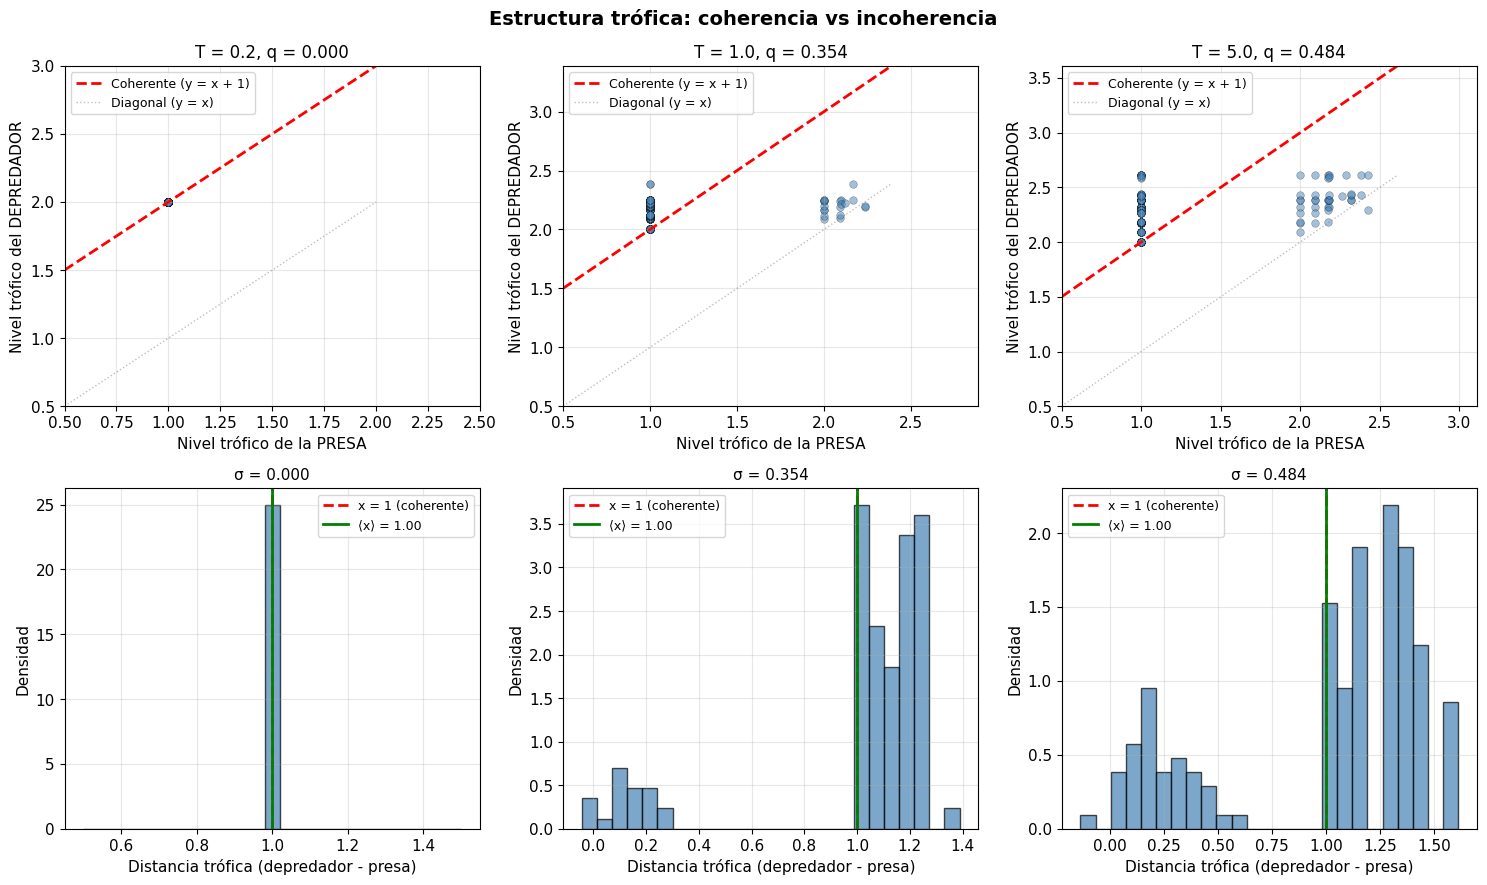


Figura 7: Estructura trófica de las redes generadas.
Panel superior: Cada punto es un enlace (presa → depredador).
  - Red coherente: puntos cerca de la línea roja (y = x + 1).
  - Red incoherente: puntos dispersos.
Panel inferior: Distribución de distancias tróficas.
  - Red coherente: distribución estrecha centrada en x = 1.
  - Red incoherente: distribución amplia.


In [21]:
# ============================================
# Visualización de la estructura trófica
# ============================================

N = 50
B = 10
L = 150

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

T_examples = [0.2, 1.0, 5.0]

for idx, T in enumerate(T_examples):
    # Generar red
    adj, levels, basal = preferential_predation_model(N, B, L, T, seed=42)
    q = compute_trophic_coherence(adj, levels)
    
    # Extraer pares (nivel_presa, nivel_depredador) para cada enlace
    prey_levels = []
    pred_levels = []
    for i in range(N):
        for j in range(N):
            if adj[i, j] == 1:  # i come a j
                prey_levels.append(levels[j])
                pred_levels.append(levels[i])
    
    prey_levels = np.array(prey_levels)
    pred_levels = np.array(pred_levels)
    
    # Panel superior: scatter de niveles
    ax = axes[0, idx]
    ax.scatter(prey_levels, pred_levels, alpha=0.5, s=30, c='steelblue', 
               edgecolors='black', linewidths=0.3)
    
    # Línea de coherencia perfecta: depredador = presa + 1
    x_line = np.linspace(0.5, np.max(levels), 100)
    ax.plot(x_line, x_line + 1, 'r--', lw=2, label='Coherente (y = x + 1)')
    ax.plot(x_line, x_line, 'gray', linestyle=':', lw=1, alpha=0.5, label='Diagonal (y = x)')
    
    ax.set_xlabel('Nivel trófico de la PRESA', fontsize=11)
    ax.set_ylabel('Nivel trófico del DEPREDADOR', fontsize=11)
    ax.set_title(f'T = {T}, q = {q:.3f}', fontsize=12)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim(0.5, np.max(levels) + 0.5)
    ax.set_ylim(0.5, np.max(levels) + 1)
    ax.grid(True, alpha=0.3)
    
    # Panel inferior: histograma de distancias tróficas
    ax2 = axes[1, idx]
    distances = pred_levels - prey_levels
    
    ax2.hist(distances, bins=25, density=True, alpha=0.7, 
             color='steelblue', edgecolor='black')
    ax2.axvline(1, color='red', linestyle='--', lw=2, label='x = 1 (coherente)')
    ax2.axvline(np.mean(distances), color='green', linestyle='-', lw=2, 
                label=f'⟨x⟩ = {np.mean(distances):.2f}')
    
    ax2.set_xlabel('Distancia trófica (depredador - presa)', fontsize=11)
    ax2.set_ylabel('Densidad', fontsize=11)
    ax2.set_title(f'σ = {np.std(distances):.3f}', fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

plt.suptitle('Estructura trófica: coherencia vs incoherencia', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nFigura 7: Estructura trófica de las redes generadas.")
print(f"Panel superior: Cada punto es un enlace (presa → depredador).")
print(f"  - Red coherente: puntos cerca de la línea roja (y = x + 1).")
print(f"  - Red incoherente: puntos dispersos.")
print(f"Panel inferior: Distribución de distancias tróficas.")
print(f"  - Red coherente: distribución estrecha centrada en x = 1.")
print(f"  - Red incoherente: distribución amplia.")

### Discusión del Ejercicio 1

**Resultados principales:**

1. **Control de la coherencia**: El parámetro de tolerancia T controla efectivamente la coherencia trófica q:
   - T pequeño → q ≈ 0 (red coherente, niveles bien definidos)
   - T grande → q > 0 (red incoherente, niveles difusos)

2. **Relación coherencia-estabilidad**: Existe una correlación positiva entre incoherencia y la parte real del autovalor máximo:
   - Redes coherentes (q bajo) → R más negativo → más estables
   - Redes incoherentes (q alto) → R más positivo → menos estables (o inestables)

3. **Efecto del tamaño**: 
   - Redes incoherentes se vuelven más inestables al crecer (consistente con criterio de May)
   - Redes coherentes mantienen mejor su estabilidad al crecer

4. **Estructura interválica**: Las redes coherentes muestran estructura "interválica" en la matriz de adyacencia ordenada, consistente con observaciones en redes tróficas reales.

**Interpretación física:**

La coherencia trófica refleja la organización jerárquica del ecosistema. En un ecosistema coherente:
- Los depredadores se alimentan principalmente de presas del nivel inmediatamente inferior
- Esto crea una estructura en cascada eficiente para el flujo de energía
- Las perturbaciones se propagan de forma más predecible y controlable

En ecosistemas incoherentes:
- Hay muchos "saltos" en la cadena trófica (omnívoros, canibalismo)
- Los feedback loops son más frecuentes
- Las perturbaciones pueden amplificarse de forma impredecible

**Implicaciones para la ecología:**

Este modelo sugiere que la coherencia trófica es una propiedad estructural clave que permite a los ecosistemas crecer en complejidad manteniendo la estabilidad, resolviendo parcialmente la "paradoja de May" sobre diversidad y estabilidad.